In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils_jack_test import model_compile_and_fit
from utils_jack_test import plot_history

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers

tf.keras.utils.set_random_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Dataset: Fashion MNIST

Vi använder Fashion MNIST-datasetet som innehåller 28x28 pixlar gråskalebilder av klädesplagg.

Datan delas upp i träningsdata och testdata:

- Träningsdata används för att lära modellen
- Testdata används för att utvärdera modellen efter träning

In [3]:
# Laddar in Fashion MNIST-datasetet från Keras
fashion_mnist = keras.datasets.fashion_mnist

# Delar upp datan i träningsdata och testdata
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

## Datans struktur

Undersöker datans form för att förstå hur många bilder vi har och hur de är strukturerade.

Varje bild är 28x28 pixlar och lagras som en matris med siffror.

In [4]:
# Skriver ut form (shape) på tränings- och testdata för att förstå datans storlek

print(np.unique(y_train))

print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)

print('X_test shape:', X_test.shape)
print('y_test shape:', y_test.shape)

[0 1 2 3 4 5 6 7 8 9]
X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


## Hur bild 1 egentligen ser ut

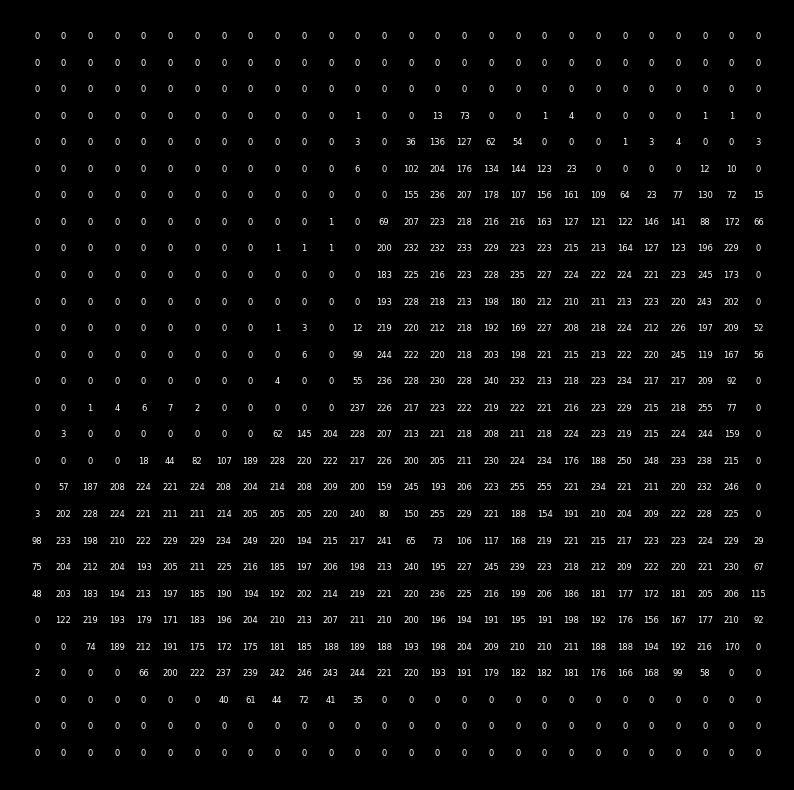

In [5]:

image = X_train[0].squeeze()

fig, ax = plt.subplots(figsize=(10,10))

fig.patch.set_facecolor('black')
ax.set_facecolor('black')

for row in range(28):
    for col in range(28):

        value = image[row, col]

        ax.text(
            col,
            row,
            str(value),
            ha='center',
            va='center',
            fontsize=6,
            color='white'
        )

ax.set_xlim(-1, 28)
ax.set_ylim(28, -1)

ax.axis('off')

plt.show()

## Efter normalisering

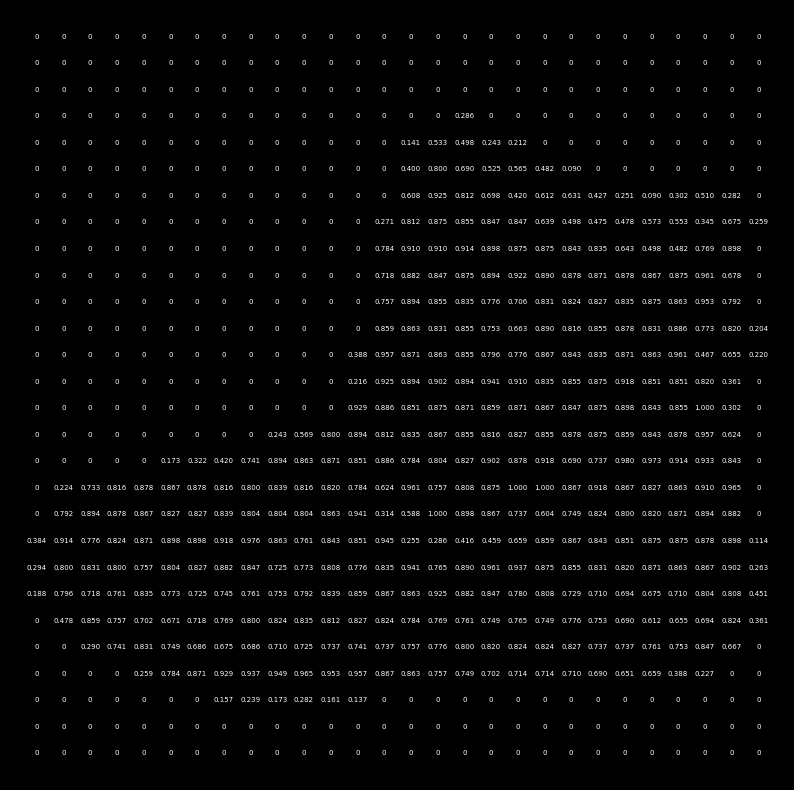

In [6]:

image = X_train[0].squeeze()

fig, ax = plt.subplots(figsize=(10,10))

fig.patch.set_facecolor('black')
ax.set_facecolor('black')

for row in range(28):
    for col in range(28):

        value = image[row, col] / 255

        if value < 0.09:
            text = "0"
        else:
            text = f"{value:.3f}"

        ax.text(
            col,
            row,
            text,
            ha='center',
            va='center',
            fontsize=5,
            color='white'
        )

ax.set_xlim(-1, 28)
ax.set_ylim(28, -1)

ax.axis('off')

plt.show()

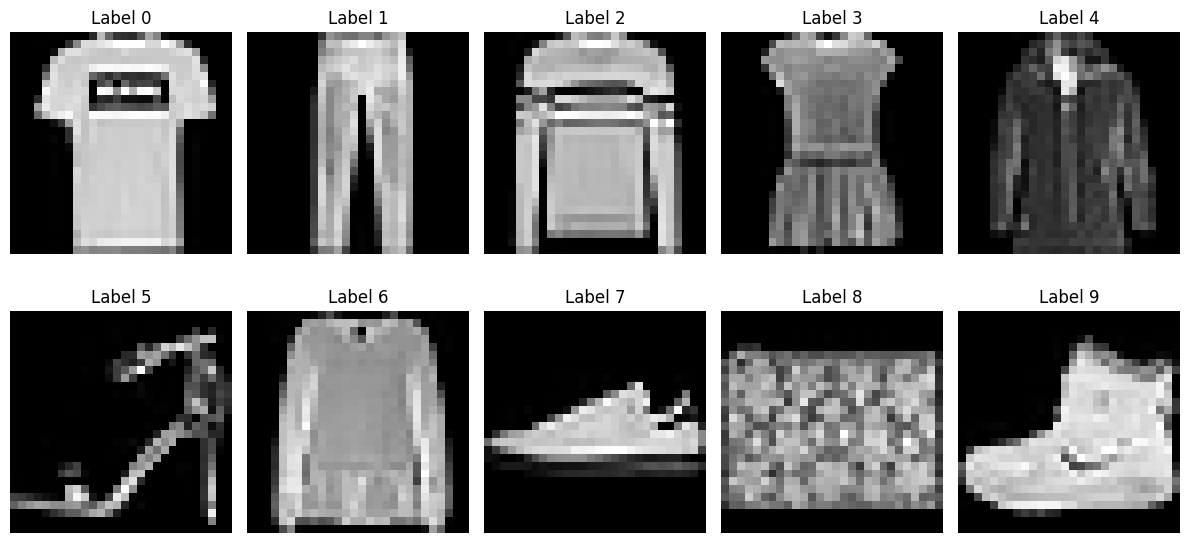

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for label in range(10):

    index = np.where(y_train == label)[0][0] # första [0] hämtar arrayen med alla index som har samma label. Andra [0] tar första indexet i arrayen.

    ax = axes[label // 5, label % 5] #vilken rad, kolumn? För rad gäller heltals div, t.ex. label 4 blir 4//5 vilket blir 0. För kolumn gäller modulus, vad blir resten? 4%5 = 4.

    ax.imshow(X_train[index], cmap="gray") # Plottar på rätt ställe med rätt bild i gråskala
    ax.set_title(f"Label {label}")# Skriver ut label med rätt siffra/index
    ax.axis("off")

plt.tight_layout()
plt.show()

## Klassnamn

Eftersom labels i datan är siffror (0–9) använder vi en lista med klassnamn för att göra resultaten mer begripliga.

In [8]:
# Lista med klassnamn som motsvarar siffrorna (0–9) i datasetet
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

for i, name in enumerate(class_names):
    print(i, name)

0 T-shirt/top
1 Trouser
2 Pullover
3 Dress
4 Coat
5 Sandal
6 Shirt
7 Sneaker
8 Bag
9 Ankle boot


## Visualisering av en bild

Visar en enskild bild från datasetet för att förstå hur datan ser ut och hur den kopplas till rätt klass.

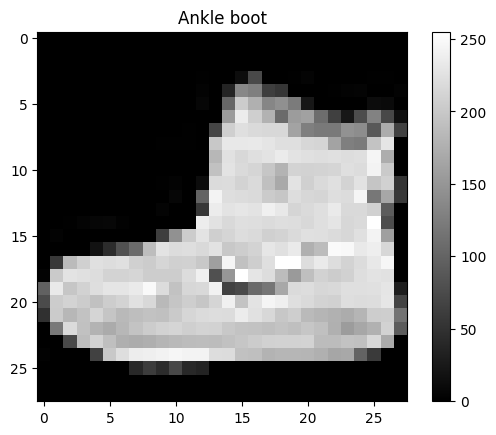

In [9]:
# Visar första bilden i träningsdatan
plt.imshow(X_train[0], cmap='gray')

# Lägger till titel med rätt klassnamn för bilden
plt.title(class_names[y_train[0]])

# Visar färgskalan (pixelvärden)
plt.colorbar()
plt.show()

## Flera exempelbilder

Visar flera bilder samtidigt för att få en bättre känsla för variationen i datasetet och hur olika klasser ser ut.

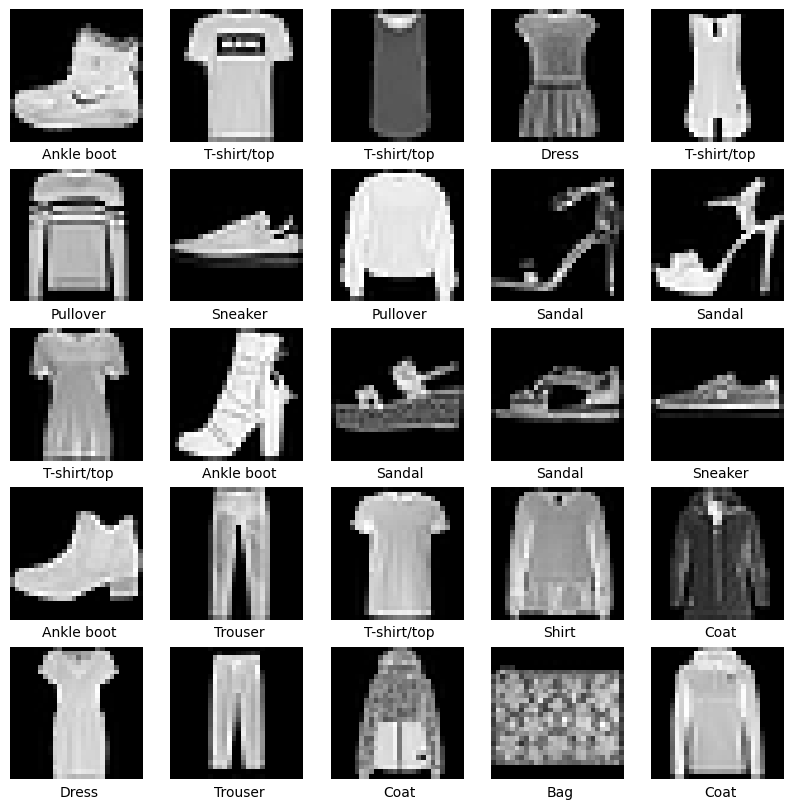

In [10]:
# Visar de första 25 bilderna i träningsdatan i ett 5x5 rutnät,
# tillsammans med respektive klassnamn för att enkelt kunna koppla bild till kategori
plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.text(
        14,
        31,
        class_names[y_train[i]],
        ha='center',
        fontsize=10
    )
    plt.axis('off')

plt.show()

## Klassfördelning

Räknar antal bilder per klass för att se om datasetet är balanserat.

Ett balanserat dataset är viktigt eftersom modellen då tränas jämnt på alla klasser.

In [11]:
# Räknar hur många bilder som finns i varje klass i träningsdatan
unique, counts = np.unique(y_train, return_counts=True)

# Skriver ut antal bilder per klass för att kontrollera datans fördelning
for label, count in zip(unique, counts):
    print(class_names[label], ':', count)

T-shirt/top : 6000
Trouser : 6000
Pullover : 6000
Dress : 6000
Coat : 6000
Sandal : 6000
Shirt : 6000
Sneaker : 6000
Bag : 6000
Ankle boot : 6000


## X

In [12]:
# Skapa valideringsset

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (48000, 28, 28)
X_val: (12000, 28, 28)
y_train: (48000,)
y_val: (12000,)


In [13]:
# Lägga till kanal-dimension till X_train

X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("X_train shape efter kanal-dimension:", X_train.shape)
print("X_val shape efter kanal-dimension:", X_val.shape)
print("X_test shape efter kanal-dimension:", X_test.shape)

X_train shape efter kanal-dimension: (48000, 28, 28, 1)
X_val shape efter kanal-dimension: (12000, 28, 28, 1)
X_test shape efter kanal-dimension: (10000, 28, 28, 1)


## X

In [14]:
# Normalisera

X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0

X_test_norm = X_test.astype("float32") / 255.0

print(f"X_train min/max: {X_train.min()} / {X_train.max().round(2)}")
print(f"X_val min/max: {X_val.min()} / {X_val.max().round(2)}")
print(f"X_test min/max: {X_test_norm.min()} / {X_test_norm.max().round(2)}")
print("X_train shape:", X_train.shape)

X_train min/max: 0.0 / 1.0
X_val min/max: 0.0 / 1.0
X_test min/max: 0.0 / 1.0
X_train shape: (48000, 28, 28, 1)


## X

In [15]:
# Basmodell

baseline_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])


## X

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8512 - loss: 0.4123 - val_accuracy: 0.8620 - val_loss: 0.3818
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8885 - loss: 0.3044 - val_accuracy: 0.8764 - val_loss: 0.3539
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9027 - loss: 0.2597 - val_accuracy: 0.8901 - val_loss: 0.3545
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9122 - loss: 0.2367 - val_accuracy: 0.8813 - val_loss: 0.3934
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9219 - loss: 0.2141 - val_accuracy: 0.8831 - val_loss: 0.4236

Resultat för Basmodell:
Antal epoker:        5
Train accuracy:      0.9027
Train loss:          0.2597
Validation accuracy: 0.8901
Validation loss:     0.3545
Träningstid:         29.20 sekunder


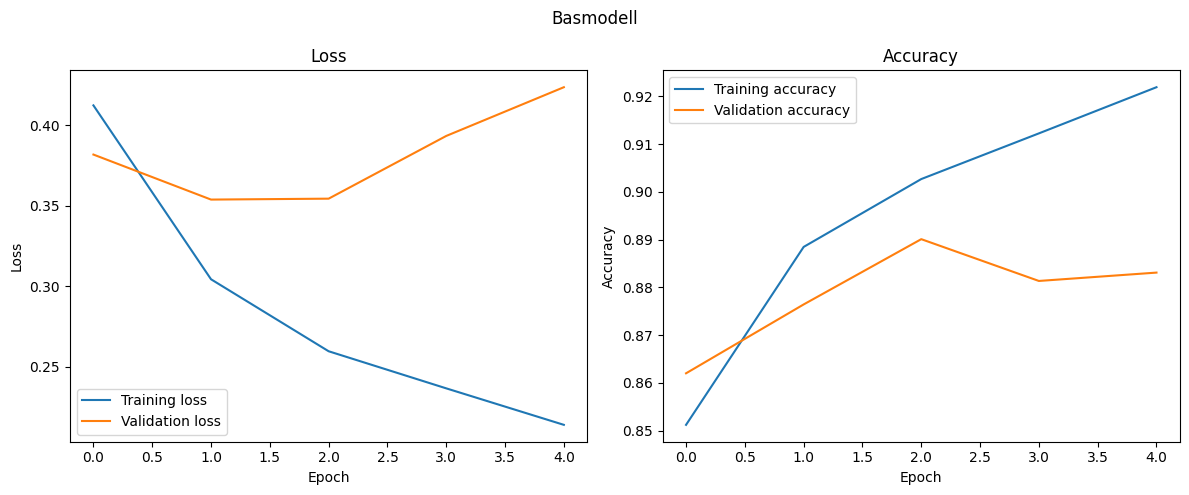

     name  train_accuracy  train_loss  validation_accuracy  validation_loss  epochs_trained  learning_rate  training_time
Basmodell        0.902667    0.259746             0.890083         0.354451               5           0.01      29.198258


In [16]:
# Compilerar och tränar basmodellen


results = []

# h_bas, r_bas = model_compile_and_fit(baseline_model, X_train, y_train, X_val, y_val, name="Basmodell")
# results.extend([r_bas])

baseline_model_trained, h_bas, r_bas = model_compile_and_fit(
    baseline_model,
    X_train,
    y_train,
    X_val,
    y_val,
    name="Basmodell"
)

results.append(r_bas)

print(pd.DataFrame(results).to_string(index=False))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


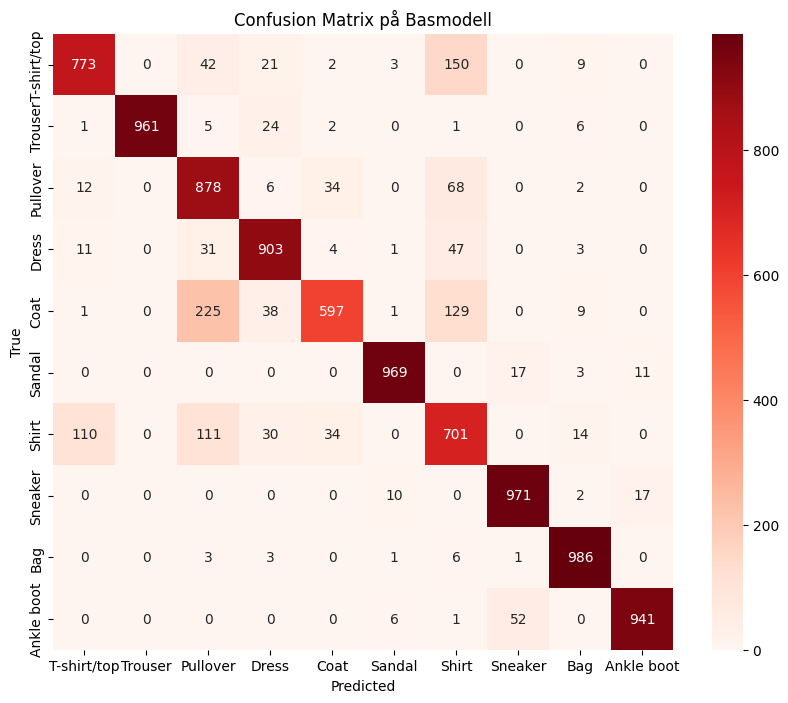

In [17]:
y_pred = baseline_model_trained.predict(X_test_norm)
y_pred_labels = np.argmax(y_pred, axis=1)


cm = confusion_matrix(y_test, y_pred_labels)
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix på Basmodell")
plt.show()

## X

In [18]:
# Förbättrad modell med ett till Conv2D-block

improved_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu",),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8223 - loss: 0.4915 - val_accuracy: 0.8561 - val_loss: 0.3796
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8574 - loss: 0.3849 - val_accuracy: 0.8807 - val_loss: 0.3280
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8663 - loss: 0.3652 - val_accuracy: 0.8759 - val_loss: 0.3523
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8692 - loss: 0.3555 - val_accuracy: 0.8859 - val_loss: 0.3283
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8743 - loss: 0.3437 - val_accuracy: 0.8860 - val_loss: 0.3263
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8769 - loss: 0.3351 - val_accuracy: 0.8881 - val_loss: 0.3354
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8778 - loss: 0.3345 - val_accuracy: 0.8795 - val_loss: 0.3637
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8796 - loss: 0.3297 - 

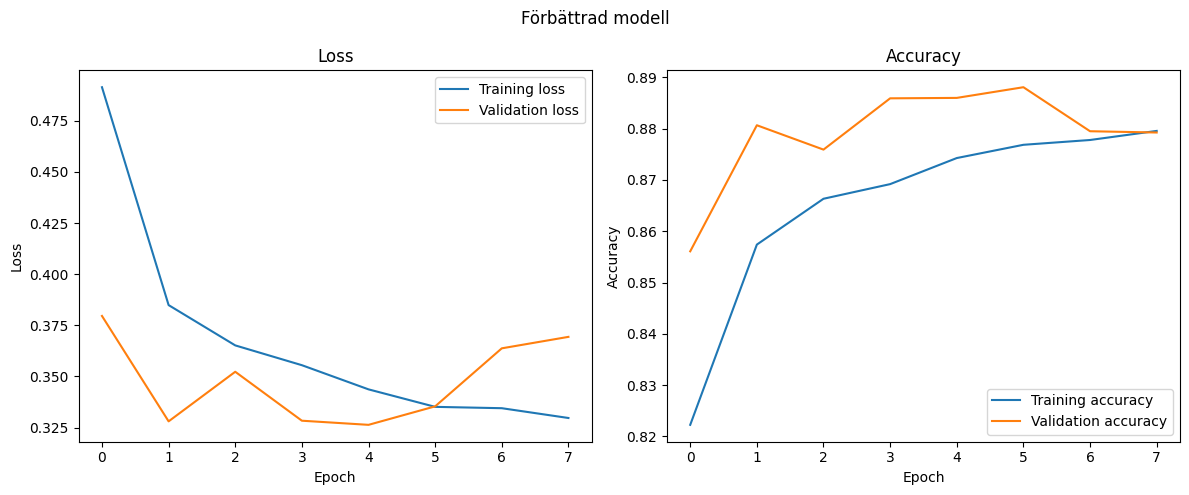

,name,train_accuracy,train_loss,validation_accuracy,validation_loss,epochs_trained,learning_rate,training_time
0,Basmodell,0.902667,0.259746,0.890083,0.354451,5,0.01,29.198258
1,Förbättrad modell,0.876854,0.335119,0.888083,0.335365,8,0.01,59.158678


In [19]:
# Compilerar och tränar förbättrad modell

improved_model_trained, h_imp, r_imp = model_compile_and_fit(
    improved_model,
    X_train,
    y_train,
    X_val,
    y_val,
    name="Förbättrad modell"
)
results.append(r_imp)

display(pd.DataFrame(results))

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6493 - loss: 0.9602 - val_accuracy: 0.7675 - val_loss: 0.6171
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7772 - loss: 0.6027 - val_accuracy: 0.8082 - val_loss: 0.5224
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8085 - loss: 0.5215 - val_accuracy: 0.8155 - val_loss: 0.4817
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8271 - loss: 0.4719 - val_accuracy: 0.8397 - val_loss: 0.4317
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8396 - loss: 0.4382 - val_accuracy: 0.8563 - val_loss: 0.3932
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8462 - loss: 0.4180 - val_accuracy: 0.8533 - val_loss: 0.3918
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8559 - loss: 0.3958 - val_accuracy: 0.8515 - val_loss: 0.3987
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8614 - loss: 0.3796 - 

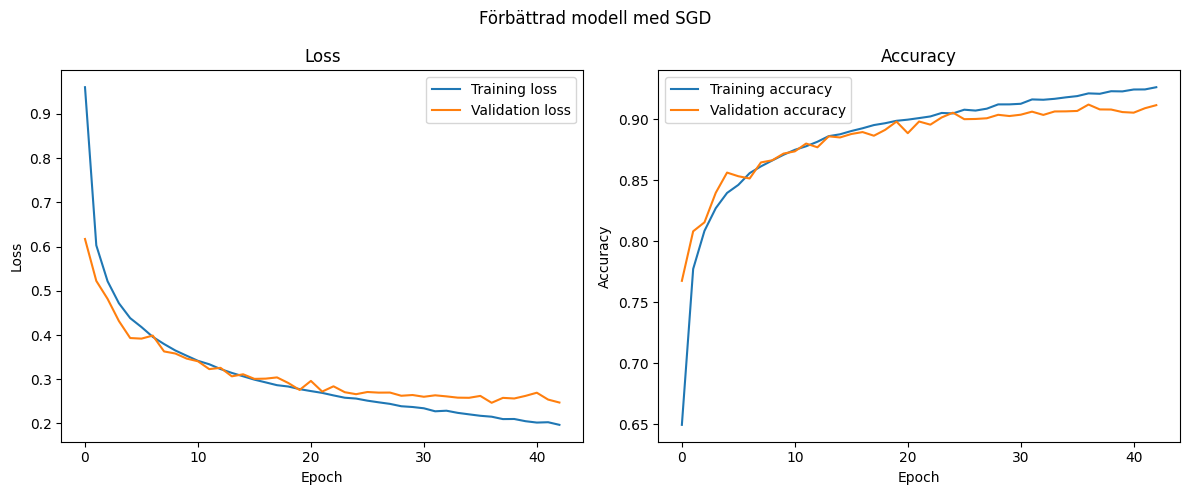

,name,train_accuracy,train_loss,validation_accuracy,validation_loss,epochs_trained,learning_rate,training_time
0,Basmodell,0.902667,0.259746,0.890083,0.354451,5,0.01,29.198258
1,Förbättrad modell,0.876854,0.335119,0.888083,0.335365,8,0.01,59.158678
2,Förbättrad modell med SGD,0.921333,0.215321,0.912167,0.246786,43,0.01,291.357627


In [20]:
# Experiment SGD optimerare


sgd_model_trained, h_sgd, r_sgd = model_compile_and_fit(
    improved_model,
    X_train,
    y_train,
    X_val,
    y_val,
    name="Förbättrad modell med SGD",
    optimizer="sgd",
    patience=6
)

results.append(r_sgd)

display(pd.DataFrame(results))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


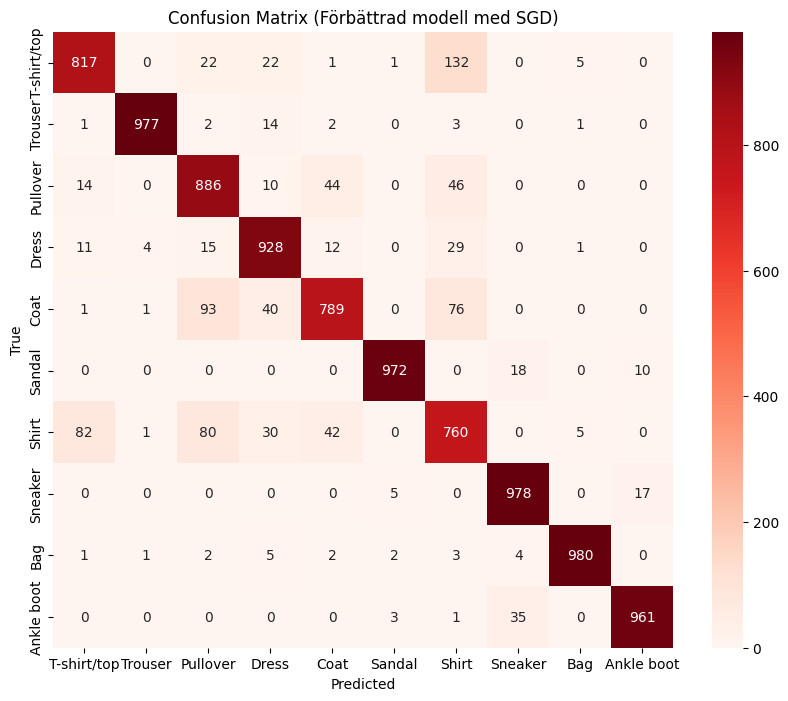

In [25]:
y_pred = sgd_model_trained.predict(X_test_norm)
y_pred_labels = np.argmax(y_pred, axis=1)


cm = confusion_matrix(y_test, y_pred_labels)
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Förbättrad modell med SGD)")
plt.show()

In [22]:
# Experiment med SGD optimerare

learning_rates = [0.05, 0.1, 0.12]


for lr in learning_rates:

    sgd_model_trained, h_sgd, r_sgd = model_compile_and_fit(
        improved_model,
        X_train,
        y_train,
        X_val,
        y_val,
        name=f"Förbättrad modell med SGD",
        optimizer="sgd",
        learning_rate=lr,
        verbose_output=False,
        patience=10
    )

    results.append(r_sgd)


display(pd.DataFrame(results))

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7451 - loss: 0.6744 - val_accuracy: 0.8413 - val_loss: 0.4339
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8450 - loss: 0.4249 - val_accuracy: 0.8426 - val_loss: 0.4208
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8654 - loss: 0.3688 - val_accuracy: 0.8722 - val_loss: 0.3459
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8793 - loss: 0.3325 - val_accuracy: 0.8767 - val_loss: 0.3292
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8861 - loss: 0.3092 - val_accuracy: 0.8883 - val_loss: 0.2964
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8943 - loss: 0.2892 - val_accuracy: 0.8889 - val_loss: 0.3019
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8994 - loss: 0.2733 - val_accuracy: 0.8911 - val_loss: 0.2895
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9051 - loss: 0.2571 - 

,name,train_accuracy,train_loss,validation_accuracy,validation_loss,epochs_trained,learning_rate,training_time
0,Basmodell,0.902667,0.259746,0.890083,0.354451,5,0.01,29.198258
1,Förbättrad modell,0.876854,0.335119,0.888083,0.335365,8,0.01,59.158678
2,Förbättrad modell med SGD,0.921333,0.215321,0.912167,0.246786,43,0.01,291.357627
3,Förbättrad modell med SGD,0.956042,0.118273,0.919250,0.264989,26,0.05,167.817103
4,Förbättrad modell med SGD,0.945104,0.145869,0.921583,0.264144,18,0.10,119.134056
5,Förbättrad modell med SGD,0.961187,0.103525,0.920750,0.284211,19,0.12,126.509041


### Testar att ändra patience till högre än 3 eftersom SGD förbättras långsammare än adam. SGD fastnar på platåer innan den plötsligt börjar förbättras igen. Så om man stoppar den lika tidigt som Adam så ger man inte den full potential. Den verkar även fungera bättre med något högre LR än de andra.

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8300 - loss: 0.4751 - val_accuracy: 0.8773 - val_loss: 0.3288
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8915 - loss: 0.3046 - val_accuracy: 0.8943 - val_loss: 0.2849
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9062 - loss: 0.2621 - val_accuracy: 0.9038 - val_loss: 0.2551
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9164 - loss: 0.2364 - val_accuracy: 0.9112 - val_loss: 0.2435
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9225 - loss: 0.2215 - val_accuracy: 0.9152 - val_loss: 0.2376
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9256 - loss: 0.2097 - val_accuracy: 0.9105 - val_loss: 0.2549
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9289 - loss: 0.2021 - val_accuracy: 0.9046 - val_loss: 0.2638
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9304 - loss: 0.2009 - 

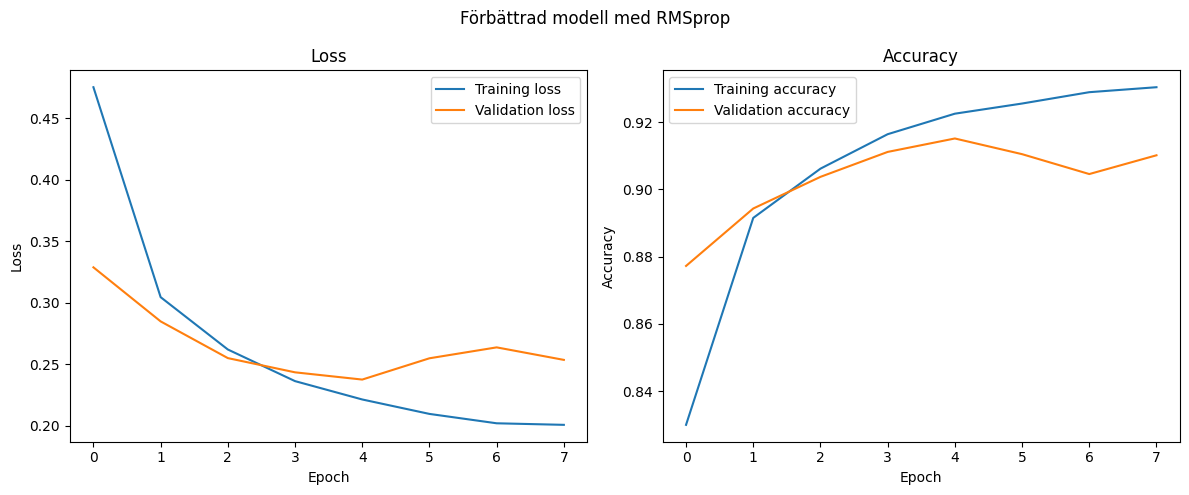

,name,train_accuracy,train_loss,validation_accuracy,validation_loss,epochs_trained,learning_rate,training_time
0,Basmodell,0.902667,0.259746,0.890083,0.354451,5,0.010,29.198258
1,Förbättrad modell,0.876854,0.335119,0.888083,0.335365,8,0.010,59.158678
2,Förbättrad modell med SGD,0.921333,0.215321,0.912167,0.246786,43,0.010,291.357627
3,Förbättrad modell med SGD,0.956042,0.118273,0.919250,0.264989,26,0.050,167.817103
4,Förbättrad modell med SGD,0.945104,0.145869,0.921583,0.264144,18,0.100,119.134056
5,Förbättrad modell med SGD,0.961187,0.103525,0.920750,0.284211,19,0.120,126.509041
6,Förbättrad modell med RMSprop,0.097333,3.551942,0.100000,2.311134,6,0.050,42.973139
7,Förbättrad modell med RMSprop,0.922542,0.221471,0.915167,0.237637,8,0.001,56.736783


In [24]:
# Experiment RMSprop optimerare


rms_model_trained, h_rms, r_rms = model_compile_and_fit(
    improved_model,
    X_train,
    y_train,
    X_val,
    y_val,
    name="Förbättrad modell med RMSprop",
    optimizer="rmsprop",
    learning_rate=0.001
)

results.append(r_rms)

display(pd.DataFrame(results))